Reinforce log vizualizer

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
# log_path = "logs_corrector/PPO_MainOne/log20250701-140710.csv"
log_path = "../logs_corrector/PPO/environement_normalized/w_noise_stacked/PPONormalJittering_20250702-112256/log.csv"
df = pd.read_csv(log_path, sep=",")



# df = df.where(df['timestep'] <= 2.32e6).dropna(how='all')
# Calculate the moving average (smoothed rewards)logs_corrector/PPO_20250630-141535/log.csv
def plot_rewards(df, window_size = 10 ) :
     # You can adjust the window size as needed
    df['smoothed_reward'] = df['reward'].rolling(window=window_size, min_periods=1).mean()

    # Set the figure size
    plt.figure(figsize=(12, 6))

    # Create the line plot for the original rewards
    sns.lineplot(x="timestep", y="reward", data=df, errorbar=("se", 2),
                color="#1f77b4", linewidth=1, label='Reward', alpha=0.5)

    # Create the line plot for the smoothed rewards
    sns.lineplot(x="timestep", y="smoothed_reward", data=df,
                color="#d62728", linewidth=2.5, label='Smoothed Reward')

    # Add title and labels
    plt.title("Reward over Timesteps", fontsize=16)
    plt.xlabel("timestep", fontsize=14)
    plt.ylabel("Reward", fontsize=14)

    # Customize the grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Customize the background and spines
    sns.set_style("whitegrid")
    sns.despine()

plot_rewards(df)
# Show the plot
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

log_path = "../logs_corrector/PPO/environement_normalized/w_noise_stacked"
path = Path(log_path)

log_df = []
rewards = []
timesteps = []
for file in path.glob("PPO*/*.csv"):
    print(file)
    df = pd.read_csv(file).where(df['timestep'] <= 2.32e6).dropna(how='all')
    # df.head()
    log_df.append(df)

    rewards.append(df['reward'].to_numpy())
    print(df['timestep'].to_numpy())
    timesteps.append(df['timestep'].to_numpy())
# log_df = pd.concat(log_df).where(df['timestep'] <= 2.32e6).dropna(how='all')

rewards = np.array(rewards)
timesteps = np.array(timesteps)

# Calculate the mean and confidence intervals
df_rewards = pd.DataFrame(rewards)
best_rewards = df_rewards.max(axis=0)
mean_rewards = df_rewards.mean(axis=0).to_numpy()
conf_interval = 1.96 * df_rewards.sem(axis=0).to_numpy()

# Plot using Seaborn
plt.figure(figsize=(12, 6))
# sns.lineplot(data=df_rewards, palette="muted", alpha=0.2)
plt.plot(timesteps[0], mean_rewards, color='red', label='Mean Reward')
plt.fill_between(timesteps[0],
                 mean_rewards - conf_interval,
                 mean_rewards + conf_interval,
                 color='blue', alpha=0.2, label='95% Confidence Interval')

In [ ]:
best_rewards = df_rewards.max(axis=0)
mean_rewards = df_rewards.mean(axis=0)

df_best_rewards = pd.DataFrame({'reward': best_rewards, 'timestep': timesteps[0]})
# best_rewards['timestep'] = timesteps[0].tolist()
# df_rewards['reward'] = best_rewards

# best_rewards.loc[:, 'timestep'] = timesteps[0].tolist(
df_best_rewards
plot_rewards(df_best_rewards)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

log_path = "../logs_corrector/log_normalized_env"
path = Path(log_path)

dfs = []

data = {}

experiments = ["Noise", "None"]
experiment_to_draw = "Noise"
for file in path.glob("*.csv"):
    # print(file.name)

    if experiment_to_draw not in file.name:
        continue
    else:
        df = pd.read_csv(file)
        if 'SAC' in file.name:
            print(file.name)
            data['user + SAC'] = df.iloc[:, 1]
        elif 'PPO' in file.name:
            data['PPO'] = df.iloc[:, 1]
        else:
            data['user'] = df.iloc[:, 1]

    # dfs.append(df)

# df = pd.concat(dfs) 
df = pd.DataFrame(data)

sns.boxplot(data=df)
plt.title("Reward gathered between different correctors for 10 correctors")
plt.ylabel("Reward")

# Visualize learned policy

== CURRENT SYSTEM INFO ==
- OS: Linux-6.8.0-60-generic-x86_64-with-glibc2.35 # 63~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue Apr 22 19:00:15 UTC 2
- Python: 3.11.5
- Stable-Baselines3: 2.4.0
- PyTorch: 2.7.1+cu126
- GPU Enabled: True
- Numpy: 1.26.4
- Cloudpickle: 3.1.1
- Gymnasium: 1.0.0

== SAVED MODEL SYSTEM INFO ==
- OS: Linux-6.8.0-60-generic-x86_64-with-glibc2.35 # 63~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue Apr 22 19:00:15 UTC 2
- Python: 3.11.5
- Stable-Baselines3: 2.4.0
- PyTorch: 2.7.1+cu126
- GPU Enabled: True
- Numpy: 1.26.4
- Cloudpickle: 3.1.1
- Gymnasium: 1.0.0

experiment to draw : noise
Policy : SAC
waiting for remote GODOT connection on port 11008
Godot Engine v4.4.1.stable.mono.official.49a5bc7b6 - https://godotengine.org
OpenGL API 3.3.0 NVIDIA 535.230.02 - Compatibility - Using Device: NVIDIA - NVIDIA RTX 2000 Ada Generation Laptop GPU

dist max is 2202.9071700823
getting command line arguments
--port=11008
--env_seed=0
--speedup=1
--num_envs=1
{ "port": "11008", "env_se

Text(0.5, 0.92, 'Player position over time for SAC on noise perturbation with reward : 9.55649995803833')

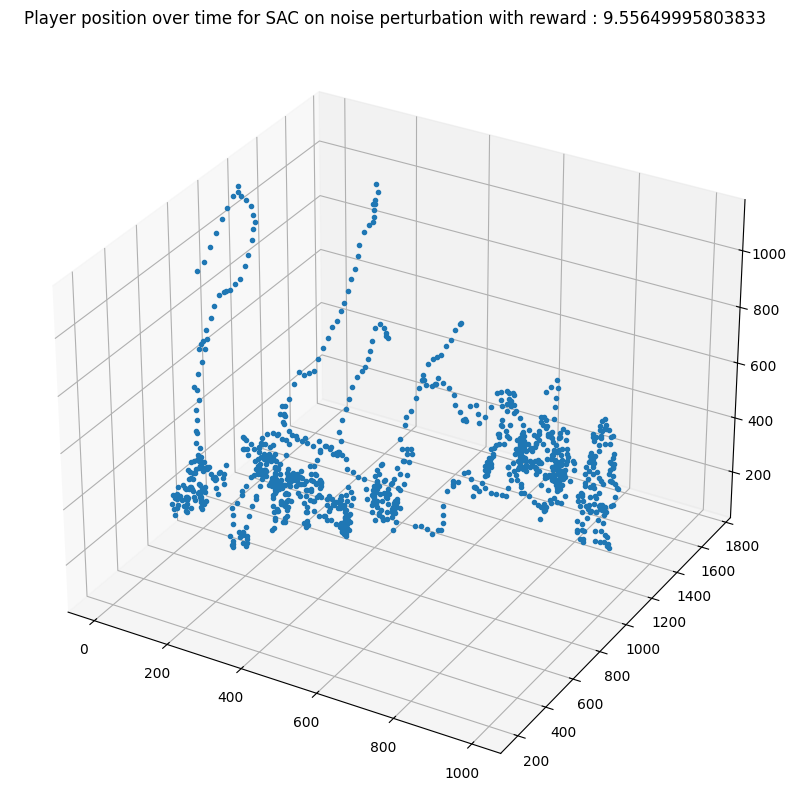

In [ ]:
import sys
from pathlib import Path
import os 
import time
import matplotlib.pyplot as plt
REPO_ROOT = Path(os.path.abspath('')).resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import stable_baselines3 as sb3
from common.rolloutenv import *
from common.perturbation import *

model_path = "/home/jmartinsaquet/Desktop/SmartDart first results /SAC_stacked_20_noise_dist/models/sac_smartdart_final.zip"


# GAME_PATH = "../" +  GAME_PATH

# env = smartDartEnv(VITE_USim([0, 0]), None, render=False, n_parallel=1, n_stack=n_stack, normalize=args.normalize, reward_shape=False)
experiments = ["noise", "None"]
experiment_to_draw =  ""

# to check in the hyperparameters file
n_stack = 20
normalized_env = True
policy = ""
if 'SAC' in model_path:
    policy = "SAC"
    model = sb3.SAC.load(model_path, print_system_info=True)
elif 'PPO' in model_path:
    policy = "PPO"
    model = sb3.PPO.load(model_path)
else:
    policy = "unknown"


for e in experiments:
    if e in model_path:
        experiment_to_draw = e


print(f"experiment to draw : {experiment_to_draw}")
print(f"Policy : {policy}")

perturbator = None
if experiment_to_draw == "noise":
    perturbator = NormalJittering(10, 20)

env = smartDartEnv(VITE_USim([0, 0]), perturbator, render=True, n_parallel=1, n_stack=n_stack, normalize=normalized_env, reward_shape=False, game_path="../" + GAME_PATH, speedup=1)



for i in range(10):
    done = False
    obs, _ = env.reset()
    a = []
    o = []
    rewards = []
    while not done:

        o.append(obs[-2:])
        action, _ = model.predict(obs, deterministic=True)
        a.append(action[-2:])
        # print("obs : ", obs, "\t action : ", action) 
        obs, reward, done, _, info = env.step(action)
        # print(f"reward : {reward}")
        rewards.append(reward)
        # time.sleep(0.001)

    print(f"reward gather for ep {i} : {sum(rewards)}")  
    SAC_player_positions = env.player_positions


env.close()


env_usim = env.godot_env
r_sum, r_list, u_sim_player_pos = rolloutSmartDartEnv(env_usim, 10000, perturbator, None) 





ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
player_positions = np.array(SAC_player_positions)
sac_tstep = np.arange(player_positions.shape[0])
ax.plot(sac_tstep, player_positions[:,0], player_positions[:,1], '.')

ax.set_title(f"Player position over time for {policy} on {experiment_to_draw} perturbation with reward : {sum(rewards)}")

In [ ]:
import matplotlib.pyplot as plt


# o = np.array(o)
# a = np.array(a)


# do = np.linalg.norm(o, axis=1) * 40
# da = np.linalg.norm(a, axis=1)

# plt.plot(do, label="obs")
# plt.plot(da, label="actions")
# plt.legend()
# plt.grid()
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
player_positions = np.array(player_positions)
sac_tstep = np.arange(player_positions.shape[0])
ax.plot(sac_tstep, player_positions[:,0], player_positions[:,1], '.')